# Kirkendall: A PFC application

In this application, Ref. [1] is reproduced.

[1]: ELDER K R, THORNTON K, HOYT J J. The Kirkendall effect in the phase field crystal model[J/OL]. Philosophical Magazine, 2011, 91(1): 151-164. DOI:10.1080/14786435.2010.506427.

## Free Energy

The free energy functional of the Kirkendall model reads:

\begin{align}
F = \int d\mathbf{x}\left[\frac{n}{2}\Lambda^0n - \frac{t}{3}n^3 + \frac{v}{4}n^4 + \gamma\psi + \frac{\omega}{2}\psi^2 + \frac{\mu}{4}\psi^4 + \frac{K}{2}\lvert\vec{\nabla\psi}\rvert^2\right]
\end{align}

where $n=n_A+n_B$, $\psi=n_A-n_B$, and 

\begin{align}
\Lambda^0 = \left(B_0^l-B_0^x\right) + B_2^l\psi^2 + B_0^x\left(1+\nabla^2\right)^2
\end{align}

### One Mode Expansion in 2D

On page 164 of *Nikolas Provatas & Ken Elder. Phase-Field Methods in Materials Science and Engineering. (Wiley-VCH Verlag GmbH & Co. KGaA, 2010). doi:10.1002/9783527631520.*, the approximated density in 2D case reads:

\begin{align}
n = \bar{n} + A\left[\frac{1}{2}cos\left(y\right)+ cos\left(\frac{\sqrt{3}}{2}x\right)cos\left(\frac{1}{2}y\right)\right]
\end{align}

Not surprisingly, the density is with triangular symmetry.

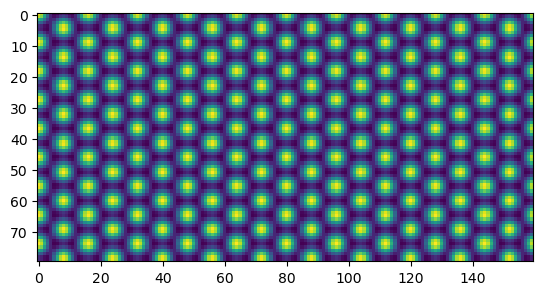

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
C = 0.5
a = 2*np.pi
dx = a /8.0
Lx = 10*a
Ly = 20*a
Nx = int(Lx/dx)
Ny = int(Ly/dx)
xlst = np.arange(Nx)*dx
ylst = np.arange(Ny)*dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
n = C*(0.5*np.cos(ymat) + np.cos(np.sqrt(3)/2*xmat)*np.cos(0.5*ymat))
plt.imshow(n)

### Free Energy per Area

The free energy per area can be computed by substituting the "one-mode-expansion" density to the free energy functional, and average per area. [This page](./pfc-pd.ipynb) can be referred.

## Implementation 

## the Kirkendall Dynamics

Order parameters $n=n_A+n_B$ and $\psi=n_A-n_B$ are all conserved:

\begin{align}
\frac{\partial n_A}{\partial t} &= M_A\nabla^2\frac{\delta F}{\delta n_A} \\
\frac{\partial n_B}{\partial t} &= M_B\nabla^2\frac{\delta F}{\delta n_B}
\end{align}

\begin{align}
F &= \int d\mathbf{x}\left[\frac{n}{2} \Lambda^0n - \frac{t}{3}n^3 + \frac{v}{4}n^4 + \gamma\psi + \frac{\omega}{2}\psi^2 + \frac{\mu}{4}\psi^4 + \frac{K}{2}\lvert\vec{\nabla\psi}\rvert^2\right]
\end{align}
where $\Lambda^0 = \left(B_0^l-B_0^x\right) + B_2^l\psi^2 + B_0^x\left(1+\nabla^2\right)^2$, such that:

|变分项|$\frac{\delta }{\delta n_A}=\frac{\delta n}{\delta n_A}\frac{\delta }{\delta n}+\frac{\delta \psi}{\delta n_A}\frac{\delta }{\delta \psi}$|$\frac{\delta }{\delta n_B}=\frac{\delta n}{\delta n_B}\frac{\delta }{\delta n}+\frac{\delta \psi}{\delta n_B}\frac{\delta }{\delta \psi}$|
|:------:|:------:|:------:|
|$\frac{n}{2}\left(B_0^l-B_0^x\right)n$|$(B_0^l-B_0^x)n$|$(B_0^l-B_0^x)n$|
|$\frac{n}{2}B_2^l\psi^2n$|$B_2^l(n\psi^2+n^2\psi)$|$B_2^l(n\psi^2-n^2\psi)$|
|$\frac{n}{2}B_0^x\left(1+\nabla^2\right)^2n$|$B_0^x\left(1+\nabla^2\right)^2n$|$B_0^x\left(1+\nabla^2\right)^2n$|
|$- \frac{t}{3}n^3 + \frac{v}{4}n^4$|$-tn^2+vn^3$|$-tn^2+vn^3$|
|$\gamma\psi + \frac{\omega}{2}\psi^2 + \frac{\mu}{4}\psi^4$|$\gamma+\omega\psi+\mu\psi^3$|$-\gamma-\omega\psi-\mu\psi^3$|
|$\frac{K}{2}\lvert\vec{\nabla\psi}\rvert^2$|$K\nabla^2\psi$|$-K\nabla^2\psi$|

### 3.1. *Single crystal: vacancy diffusion*
We first reproduce the Sec. 3.1, "a single crystal that contains an initial concentration inhomogeneity in the absence of grain boundaries, surfaces or other natural sources or sinks of vacancies". Here

\begin{align}
\psi & = psi = 
\begin{cases}
0.1\; for\; y=[-L_y/2,0] \nonumber \\
-0.1\; for\; y=[0, L_y/2] \nonumber \\ 
\end{cases}
\nonumber \\
n &= \bar{n} + C\left[\frac{1}{2}cos(y)+cos(\frac{\sqrt{3}}{2}x)cos(\frac{1}{2}y)\right] \nonumber \\
\bar{n} &= nbar = -0.1501 \nonumber \\
M_A &= MA = 1.0 \nonumber \\
M_B &= MB = 0.1 \nonumber
\end{align}

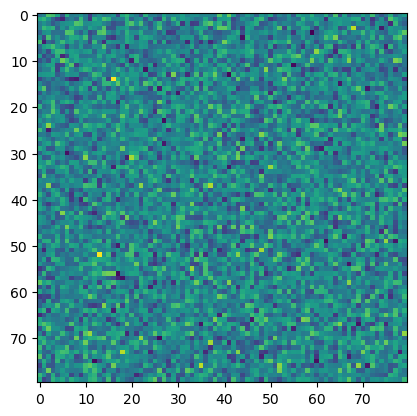

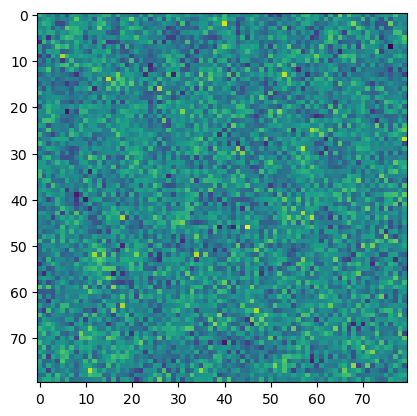

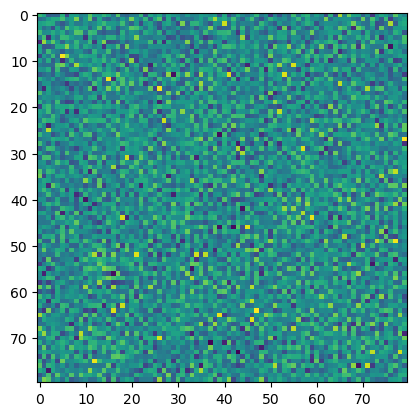

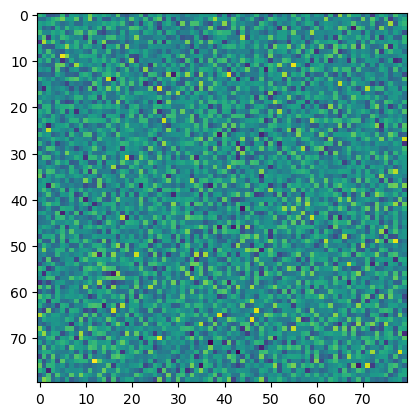

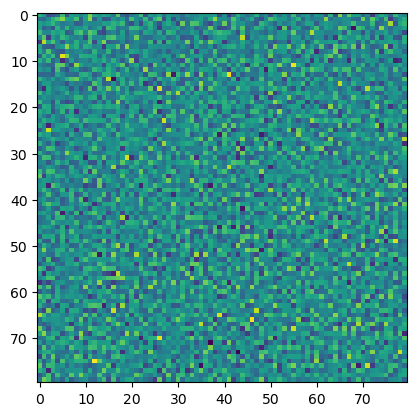

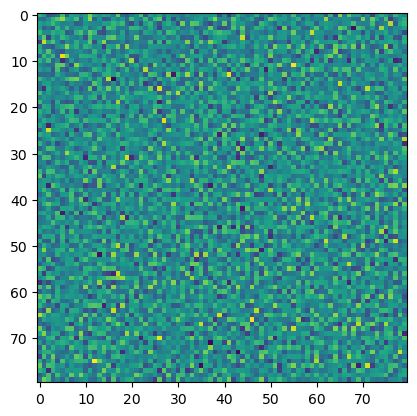

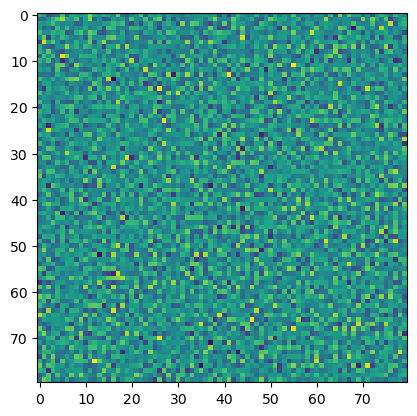

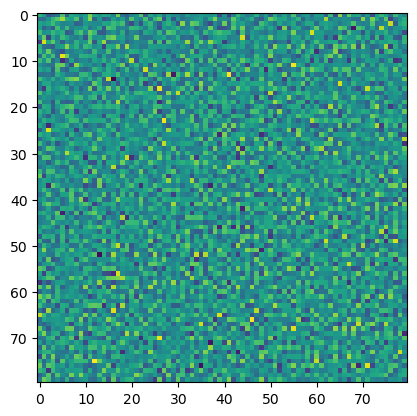

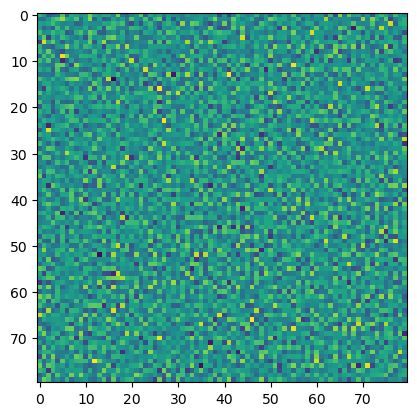

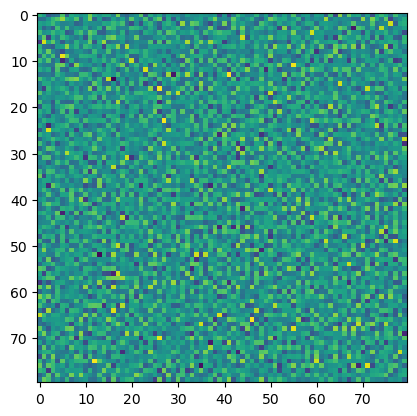

In [30]:
import numpy as np
import matplotlib.pyplot as plt
def lapCalc(phi, dx):
    phi_ipj0 = np.roll(phi, 1, axis=0) # phi_ipj0=phi(i+1,j)
    phi_imj0 = np.roll(phi, -1, axis=0) # phi_imj0=phi(i-1,j)
    phi_i0jp = np.roll(phi, 1, axis=1)
    phi_i0jm = np.roll(phi, -1, axis=1)
    phi_ipjp = np.roll(phi, (1,1), axis=(0,1))
    phi_ipjm = np.roll(phi, (1,-1), axis=(0,1))
    phi_imjp = np.roll(phi, (-1,1), axis=(0,1))
    phi_imjm = np.roll(phi, (-1,-1), axis=(0,1))
    phi_lap = (0.5*(phi_ipj0+phi_imj0+phi_i0jp+phi_i0jm)+0.25*(phi_ipjp+phi_imjp+phi_ipjm+phi_imjm)-3*phi)/(dx**2.0)
    return(phi_lap)
def t1Calc(B0l, B0x, n):
    t1 = (B0l-B0x)*n
    return(t1)
def t2ACalc(B2l, n, psi):
    t2 = B2l * (n*psi**2+n**2*psi)
    return(t2)
def t2BCalc(B2l, n, psi):
    t2 = B2l * (n*psi**2-n**2*psi)
    return(t2)
def t3Calc(B0x, dx, n):
    lapn = lapCalc(n, dx)
    lap2n = lapCalc(lapn, dx)
    t3 = B0x * (n + 2*lapn + lap2n)
    return(t3)
def t4Calc(t,v,n):
    t4 = -t*n**2 + v*n**3
    return(t4)
def t56ABCalc(g,w,u,K,dx,psi):
    t56 = g + w*psi + u*psi**3 + K*lapCalc(psi,dx)
    return(t56)
def dynACalc(B0l, B2l, B0x, t, v, w, u, K, M, dx, psi, n):
    t1 = t1Calc(B0l, B0x, n)
    t2 = t2ACalc(B2l, n, psi)
    t3 = t3Calc(B0x, dx, n)
    t4 = t4Calc(t,v,n)
    t56 = t56ABCalc(0, w, u, K, dx, psi)
    dynA = M * lapCalc(t1+t2+t3+t4+t56, dx)
    return(dynA)
def dynBCalc(B0l, B2l, B0x, t, v, w, u, K, M, dx, psi, n):
    t1 = t1Calc(B0l, B0x, n)
    t2 = t2BCalc(B2l, n, psi)
    t3 = t3Calc(B0x, dx, n)
    t4 = t4Calc(t,v,n)
    t56 = t56ABCalc(0, w, u, K, dx, psi)
    dynB = M * lapCalc(t1+t2+t3+t4-t56, dx)
    return(dynB)
# parameter list
nbar = -0.15
B0l = 0.7
B2l = -1.8
B0x = 1.0
t = 0.6
v = 1.0
K = 4.0
w = 1.0
u = 4.0
dt = 0.0000001
dx = np.pi/8
Lx = 10*np.pi
Ly = 10*np.pi
Nx = int(Lx/dx)
Ny = int(Ly/dx)
Ny_div2 = int(Ny/2)
C = 0.1
MA = 1.0
MB = 0.1
tstep = 10000
tdump = 1000
xlst = np.arange(Nx) * dx
ylst = np.arange(Ny) * dx
[xmat, ymat] = np.meshgrid(xlst, ylst,indexing='ij')
# Initialisation
psi = np.zeros((Nx, Ny))
psi[:,Ny_div2:] = 0.0
psi[:,:Ny_div2] = 0.0
# n = nbar + C*(np.cos(np.sqrt(3)/2*xmat)*np.cos(0.5*ymat)+0.5*np.cos(ymat))
n = np.random.normal(nbar, 5e-2, (Nx,Ny))
for t in range(tstep):
    nA = (n+psi)/2.0
    nB = (n-psi)/2.0
    nA = nA + dt * dynACalc(B0l, B2l, B0x, t, v, w, u, K, MA, dx, psi, n)
    nB = nB + dt * dynBCalc(B0l, B2l, B0x, t, v, w, u, K, MB, dx, psi, n)
    n = nA + nB
    psi = nA - nB
    if (t%tdump == 0):
        plt.figure()
        plt.imshow(nA)
        # plt.imshow(n[:,Ny_div2-160:Ny_div2+160]) # 样品很长，只展示中间320个单位长度的信息